# Week 6 Part A: Dual-Event Prediction Shootout

This notebook implements **Part A only** for Homework 6.

Expected input files:
- `data/scenarios/fungwong_202511.json`
- `data/scenarios/rain_20230605_snapshot.json`

## Data Source Note

- Event 1 raw JSON source: `data/scenarios/fungwong_202511.json`
- Event 2 original source file: `data/scenarios/rain_20230605.csv` (downloaded from the CoLife historical database)
- Event 2 analysis snapshot used in this notebook: `data/scenarios/rain_20230605_snapshot.json`
- The second event source is a CoLife historical CSV download. The JSON used here is a derived station snapshot extracted from `rain_20230605.csv` at `2023-06-05 01:10:00` using locally matched Hualien/Yilan station metadata.
- If the submission requires the original event files inside `submission/Homework-6`, these source files should be copied there in addition to the figures and notebook.

The notebook is intentionally trimmed to homework deliverables only:
- dual-event variogram comparison
- 2x2 interpolation comparison for each event
- Kriging vs RF difference map for each event
- Sigma Map for each event
- GeoTIFF export for Event 1 only
- compact cross-event summary table and Chinese interpretation


## 1. Setup

載入分析需要的套件，設定中文字型與輸出資料夾，並自動定位專案根目錄。

In [25]:
from pathlib import Path
import json
import warnings

import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import Markdown, display
from pykrige.ok import OrdinaryKriging
from rasterio.transform import from_origin
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != "2026_RS":
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if candidate.name == "2026_RS":
            PROJECT_ROOT = candidate
            break

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "submission" / "Homework-6"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_DIR:   {OUTPUT_DIR}")


PROJECT_ROOT: D:\YongZhi\2026_RS
OUTPUT_DIR:   D:\YongZhi\2026_RS\submission\Homework-6


## 2. Event Config

設定研究區、網格解析度、Random Forest 參數，以及兩個事件的輸入檔與標籤。

In [26]:
GRID_RESOLUTION = 1000
GRID_PADDING = 5000
RF_N_ESTIMATORS = 200
RF_MIN_SAMPLES_LEAF = 3
RANDOM_STATE = 42
STUDY_COUNTIES = {"宜蘭縣", "花蓮縣"}
# Event 2 is derived from the local CSV at data/scenarios/rain_20230605.csv.
# The snapshot used here is 2023-06-05 01:10:00, chosen because it has the highest 1-hour rainfall
# among the locally matched 宜蘭縣 / 花蓮縣 stations.

EVENTS = [
    {
        "event_id": "fungwong",
        "display_label": "Typhoon Fung-wong (2025-11-11 18:50)",
        "source_file": DATA_DIR / "scenarios" / "fungwong_202511.json",
        "event_date": "2025-11-11 18:50",
        "export_geotiff": True,
    },
    {
        "event_id": "rain20230605",
        "display_label": "Heavy Rain Event (2023-06-05 01:10)",
        "source_file": DATA_DIR / "scenarios" / "rain_20230605_snapshot.json",
        "event_date": "2023-06-05 01:10",
        "export_geotiff": False,
    },
]

pd.DataFrame(
    [
        {
            "event_id": event["event_id"],
            "label": event["display_label"],
            "source_file": str(event["source_file"]),
            "event_date": event["event_date"],
            "export_geotiff": event["export_geotiff"],
        }
        for event in EVENTS
    ]
)


,event_id,label,source_file,event_date,export_geotiff
0,fungwong,Typhoon Fung-wong (2025-11-11 18:50),D:\YongZhi\2026_RS\data\scenarios\fungwong_202...,2025-11-11 18:50,True
1,rain20230605,Heavy Rain Event (2023-06-05 01:10),D:\YongZhi\2026_RS\data\scenarios\rain_2023060...,2023-06-05 01:10,False


## 3. Load And Parse Rainfall Snapshots

定義 JSON 載入與解析函式，包含 fail-fast schema 檢查，確保第二事件資料也符合 `records.Station` 結構。

In [27]:
def _safe_float(value):
    if value in (None, "", "-998", -998):
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def load_station_snapshot(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing event file: {path}\n"
            "Place the required station snapshot at this exact path before running the notebook."
        )
    with path.open("r", encoding="utf-8-sig") as f:
        raw = json.load(f)
    return raw


def normalize_cwa_json(raw):
    if not isinstance(raw, dict):
        raise ValueError("Expected top-level JSON object for rainfall snapshot.")
    if "records" not in raw or not isinstance(raw["records"], dict):
        raise ValueError("Expected JSON to contain a 'records' object.")
    if "Station" not in raw["records"] or not isinstance(raw["records"]["Station"], list):
        raise ValueError(
            "Expected station snapshot schema with 'records.Station' list. "
            "If your CoLife file is monthly data, first extract the target snapshot and save it in that shape."
        )
    return raw["records"]["Station"]


def parse_rainfall_json(raw):
    stations = normalize_cwa_json(raw)
    parsed_rows = []

    for station in stations:
        try:
            coords = station.get("GeoInfo", {}).get("Coordinates", [])
            lat = None
            lon = None

            if len(coords) >= 2:
                for coord in coords:
                    if coord.get("CoordinateName") == "WGS84":
                        lat = _safe_float(coord.get("StationLatitude"))
                        lon = _safe_float(coord.get("StationLongitude"))
                        break
            elif len(coords) == 1:
                lat = _safe_float(coords[0].get("StationLatitude"))
                lon = _safe_float(coords[0].get("StationLongitude"))

            if pd.isna(lat) or pd.isna(lon):
                continue

            rainfall = station.get("RainfallElement", {})
            if "Past1hr" in rainfall:
                rain_1hr = _safe_float(rainfall["Past1hr"].get("Precipitation"))
            elif "Now" in rainfall:
                rain_1hr = _safe_float(rainfall["Now"].get("Precipitation"))
            else:
                rain_1hr = np.nan

            parsed_rows.append(
                {
                    "StationName": station.get("StationName", ""),
                    "StationId": station.get("StationId", ""),
                    "CountyName": station.get("GeoInfo", {}).get("CountyName", ""),
                    "TownName": station.get("GeoInfo", {}).get("TownName", ""),
                    "lat": lat,
                    "lon": lon,
                    "rain_1hr": rain_1hr,
                }
            )
        except Exception as exc:
            raise ValueError(f"Failed while parsing station record: {exc}") from exc

    if not parsed_rows:
        raise ValueError("Parsed zero station rows from the rainfall snapshot.")

    df = pd.DataFrame(parsed_rows)
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    )
    return gdf


## 4. Preprocessing And Interpolation Core

這一段負責單一事件的資料前處理、EPSG:3826 轉換、網格建立、variogram 擬合，以及四種內插方法的核心計算。

In [28]:
def prepare_event_data(event):
    raw = load_station_snapshot(event["source_file"])
    gdf = parse_rainfall_json(raw)

    total_stations = len(gdf)
    county_filtered = gdf[gdf["CountyName"].isin(STUDY_COUNTIES)].copy()
    county_stations = len(county_filtered)

    positive_rain = county_filtered[county_filtered["rain_1hr"].notna() & (county_filtered["rain_1hr"] > 0)].copy()
    positive_rain_stations = len(positive_rain)

    if positive_rain_stations < 5:
        raise ValueError(
            f"Event {event['event_id']} has only {positive_rain_stations} positive-rain stations after filtering."
        )

    projected = positive_rain.to_crs("EPSG:3826")
    projected["easting"] = projected.geometry.x
    projected["northing"] = projected.geometry.y

    stats = {
        "total_stations": total_stations,
        "county_stations": county_stations,
        "positive_rain_stations": positive_rain_stations,
        "crs_after_projection": str(projected.crs),
        "max_rain_1hr": float(projected["rain_1hr"].max()),
        "mean_rain_1hr": float(projected["rain_1hr"].mean()),
    }
    return projected, stats


def build_grid(projected_gdf, resolution=GRID_RESOLUTION, padding=GRID_PADDING):
    minx, miny, maxx, maxy = projected_gdf.total_bounds
    gridx = np.arange(minx - padding, maxx + padding + resolution, resolution)
    gridy = np.arange(miny - padding, maxy + padding + resolution, resolution)
    xx, yy = np.meshgrid(gridx, gridy)
    return {
        "gridx": gridx,
        "gridy": gridy,
        "xx": xx,
        "yy": yy,
        "shape": xx.shape,
        "bounds": (minx, miny, maxx, maxy),
    }


def fit_variogram_models(projected_gdf, candidate_models=("spherical", "exponential")):
    x = projected_gdf["easting"].to_numpy(dtype=float)
    y = projected_gdf["northing"].to_numpy(dtype=float)
    z = projected_gdf["rain_1hr"].to_numpy(dtype=float)
    z_log = np.log1p(z)

    fitted_models = []
    for model_name in candidate_models:
        ok = OrdinaryKriging(
            x,
            y,
            z_log,
            variogram_model=model_name,
            verbose=False,
            enable_plotting=False,
        )
        params = np.asarray(ok.variogram_model_parameters, dtype=float)
        if len(params) < 3:
            raise ValueError(f"Unexpected variogram parameter shape for {model_name}: {params}")

        fitted_at_lags = ok.variogram_function(params, ok.lags)
        sse = float(np.nansum((ok.semivariance - fitted_at_lags) ** 2))
        nugget = float(params[2])
        psill = float(params[0])
        full_sill = float(psill + nugget)
        vrange = float(params[1])

        fitted_models.append(
            {
                "model_name": model_name,
                "ok": ok,
                "params": params,
                "lags": np.asarray(ok.lags, dtype=float),
                "semivariance": np.asarray(ok.semivariance, dtype=float),
                "sse": sse,
                "sill": full_sill,
                "partial_sill": psill,
                "range": vrange,
                "nugget": nugget,
            }
        )

    best = min(fitted_models, key=lambda item: item["sse"])
    return {
        "x": x,
        "y": y,
        "z": z,
        "z_log": z_log,
        "models": fitted_models,
        "best": best,
    }


def run_interpolations(projected_gdf, grid, variogram_result):
    x = variogram_result["x"]
    y = variogram_result["y"]
    z = variogram_result["z"]
    xx = grid["xx"]
    yy = grid["yy"]
    gridx = grid["gridx"]
    gridy = grid["gridy"]
    best = variogram_result["best"]

    z_kriging_log, ss_kriging = best["ok"].execute("grid", gridx, gridy)
    z_kriging = np.expm1(np.asarray(z_kriging_log, dtype=float))
    ss_kriging = np.asarray(ss_kriging, dtype=float)

    train_xy = np.column_stack([x, y])
    grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

    nn_model = NearestNDInterpolator(train_xy, z)
    z_nn = np.asarray(nn_model(xx, yy), dtype=float)

    dists = cdist(grid_pts, train_xy)
    zero_rows = np.any(dists == 0, axis=1)
    z_idw_flat = np.empty(grid_pts.shape[0], dtype=float)
    if zero_rows.any():
        zero_station_idx = np.argmax(dists[zero_rows] == 0, axis=1)
        z_idw_flat[zero_rows] = z[zero_station_idx]
    nonzero_rows = ~zero_rows
    if nonzero_rows.any():
        weights = 1.0 / np.power(dists[nonzero_rows], 2)
        weights /= weights.sum(axis=1, keepdims=True)
        z_idw_flat[nonzero_rows] = weights @ z
    z_idw = z_idw_flat.reshape(xx.shape)

    rf = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE,
    )
    rf.fit(train_xy, z)
    z_rf = rf.predict(grid_pts).reshape(xx.shape)

    return {
        "z_nn": z_nn,
        "z_idw": z_idw,
        "z_kriging": z_kriging,
        "ss_kriging": ss_kriging,
        "z_rf": z_rf,
        "diff_kriging_rf": z_kriging - z_rf,
        "rf_model": rf,
    }


## 5. Figure And Raster Helpers

定義所有作業輸出函式，包括 variogram 圖、2×2 比較圖、Kriging vs RF 差異圖、Sigma Map，以及 GeoTIFF 匯出與驗證。

In [29]:
def _grid_extent_km(grid):
    return [
        grid["gridx"].min() / 1000,
        grid["gridx"].max() / 1000,
        grid["gridy"].min() / 1000,
        grid["gridy"].max() / 1000,
    ]


def save_variogram_figure(event, variogram_result):
    fig, ax = plt.subplots(figsize=(8, 6))
    first_model = variogram_result["models"][0]
    ax.scatter(
        first_model["lags"] / 1000,
        first_model["semivariance"],
        c="black",
        s=35,
        label="Empirical",
        zorder=3,
    )

    lag_range = np.linspace(0, first_model["lags"].max() * 1.05, 200)
    for model in variogram_result["models"]:
        fitted = model["ok"].variogram_function(model["params"], lag_range)
        linestyle = "-" if model["model_name"] == variogram_result["best"]["model_name"] else "--"
        linewidth = 2.5 if linestyle == "-" else 1.8
        ax.plot(
            lag_range / 1000,
            fitted,
            linestyle=linestyle,
            linewidth=linewidth,
            label=f"{model['model_name']} (SSE={model['sse']:.4f})",
        )

    best = variogram_result["best"]
    ax.set_title(f"{event['display_label']} Variogram Comparison")
    ax.set_xlabel("Lag distance (km)")
    ax.set_ylabel("Semivariance")
    ax.legend()
    ax.text(
        0.02,
        0.98,
        f"Best: {best['model_name']}\nSill={best['sill']:.3f}\nRange={best['range']:.1f} m\nNugget={best['nugget']:.3f}",
        transform=ax.transAxes,
        va="top",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
    )
    fig.tight_layout()
    output_path = OUTPUT_DIR / f"{event['event_id']}_variogram_compare.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return output_path


def save_methods_2x2_figure(event, projected_gdf, grid, surfaces, variogram_result):
    extent = _grid_extent_km(grid)
    station_x = projected_gdf["easting"].to_numpy() / 1000
    station_y = projected_gdf["northing"].to_numpy() / 1000
    station_rain = projected_gdf["rain_1hr"].to_numpy()

    arrays = [
        ("Nearest Neighbor", surfaces["z_nn"]),
        ("IDW (power=2)", surfaces["z_idw"]),
        (f"Ordinary Kriging ({variogram_result['best']['model_name']})", surfaces["z_kriging"]),
        ("Random Forest", surfaces["z_rf"]),
    ]
    vmax = max(float(np.nanmax(arr)) for _, arr in arrays)

    fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
    for ax, (title, array) in zip(axes.ravel(), arrays):
        im = ax.imshow(array, origin="lower", extent=extent, cmap="viridis", vmin=0, vmax=vmax)
        ax.scatter(station_x, station_y, c=station_rain, cmap="viridis", vmin=0, vmax=vmax, s=20, edgecolor="white", linewidth=0.4)
        ax.set_title(title)
        ax.set_xlabel("Easting (km)")
        ax.set_ylabel("Northing (km)")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.88)
    cbar.set_label("Rainfall (mm/hr)")
    fig.suptitle(f"{event['display_label']} Interpolation Shootout", fontsize=16)
    output_path = OUTPUT_DIR / f"{event['event_id']}_methods_2x2.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return output_path


def save_difference_figure(event, projected_gdf, grid, surfaces):
    extent = _grid_extent_km(grid)
    station_x = projected_gdf["easting"].to_numpy() / 1000
    station_y = projected_gdf["northing"].to_numpy() / 1000
    station_rain = projected_gdf["rain_1hr"].to_numpy()
    diff = surfaces["diff_kriging_rf"]
    rain_vmax = max(float(np.nanmax(surfaces["z_kriging"])), float(np.nanmax(surfaces["z_rf"])))
    diff_vlim = float(np.nanmax(np.abs(diff)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    im0 = axes[0].imshow(surfaces["z_kriging"], origin="lower", extent=extent, cmap="viridis", vmin=0, vmax=rain_vmax)
    axes[0].scatter(station_x, station_y, c=station_rain, cmap="viridis", vmin=0, vmax=rain_vmax, s=18, edgecolor="white", linewidth=0.35)
    axes[0].set_title("Ordinary Kriging")

    im1 = axes[1].imshow(surfaces["z_rf"], origin="lower", extent=extent, cmap="viridis", vmin=0, vmax=rain_vmax)
    axes[1].scatter(station_x, station_y, c=station_rain, cmap="viridis", vmin=0, vmax=rain_vmax, s=18, edgecolor="white", linewidth=0.35)
    axes[1].set_title("Random Forest")

    im2 = axes[2].imshow(diff, origin="lower", extent=extent, cmap="RdBu_r", vmin=-diff_vlim, vmax=diff_vlim)
    axes[2].scatter(station_x, station_y, c="black", s=12, alpha=0.7)
    axes[2].set_title("Difference (Kriging - RF)")

    for ax in axes:
        ax.set_xlabel("Easting (km)")
        ax.set_ylabel("Northing (km)")

    cbar0 = fig.colorbar(im1, ax=axes[:2], shrink=0.88)
    cbar0.set_label("Rainfall (mm/hr)")
    cbar1 = fig.colorbar(im2, ax=axes[2], shrink=0.88)
    cbar1.set_label("Kriging - RF (mm/hr)")
    fig.suptitle(f"{event['display_label']} Kriging vs RF", fontsize=16)
    output_path = OUTPUT_DIR / f"{event['event_id']}_kriging_vs_rf_diff.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return output_path


def save_sigma_figure(event, projected_gdf, grid, surfaces):
    extent = _grid_extent_km(grid)
    station_x = projected_gdf["easting"].to_numpy() / 1000
    station_y = projected_gdf["northing"].to_numpy() / 1000

    fig, ax = plt.subplots(figsize=(8.5, 7.2), constrained_layout=True)
    im = ax.imshow(surfaces["ss_kriging"], origin="lower", extent=extent, cmap="Blues")
    ax.scatter(station_x, station_y, c="black", s=16, edgecolor="white", linewidth=0.35)
    ax.set_title(f"{event['display_label']} Sigma Map")
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    cbar = fig.colorbar(im, ax=ax, shrink=0.92)
    cbar.set_label("Kriging variance")
    output_path = OUTPUT_DIR / f"{event['event_id']}_sigma_map.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return output_path


def save_geotiff(data, grid, filename, crs="EPSG:3826"):
    data_flipped = np.flipud(np.asarray(data, dtype=np.float32))
    west = float(grid["gridx"].min() - GRID_RESOLUTION / 2)
    north = float(grid["gridy"].max() + GRID_RESOLUTION / 2)
    transform = from_origin(west, north, GRID_RESOLUTION, GRID_RESOLUTION)
    output_path = OUTPUT_DIR / filename

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(data_flipped, 1)

    return output_path


def validate_raster(path):
    with rasterio.open(path) as src:
        return {
            "path": str(path),
            "width": src.width,
            "height": src.height,
            "crs": str(src.crs),
            "dtype": src.dtypes[0],
            "transform": tuple(src.transform)[:6],
        }


## 6. Run Dual-Event Analysis

逐一執行兩個事件的完整流程，並把關鍵圖表直接顯示在 notebook 內，同時將檔案寫到 `submission/Homework-6`。

Running event: Typhoon Fung-wong (2025-11-11 18:50)


## Typhoon Fung-wong (2025-11-11 18:50)

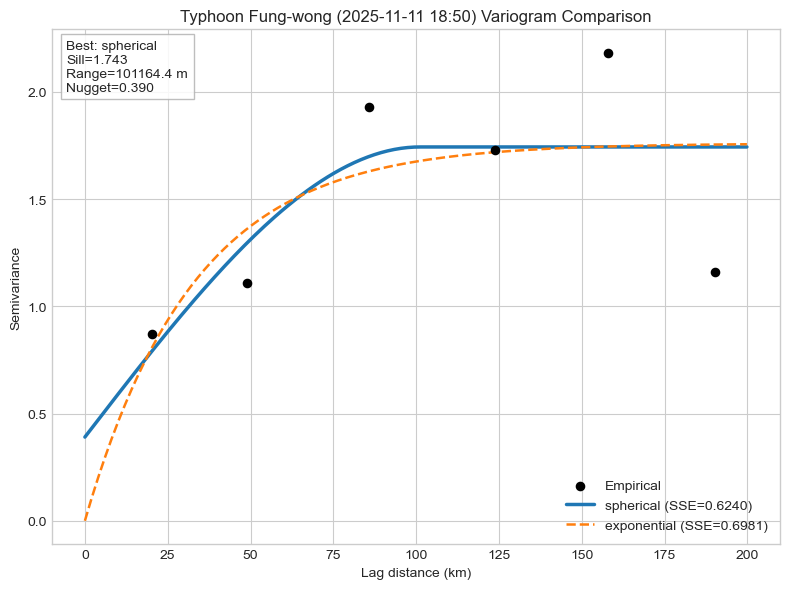

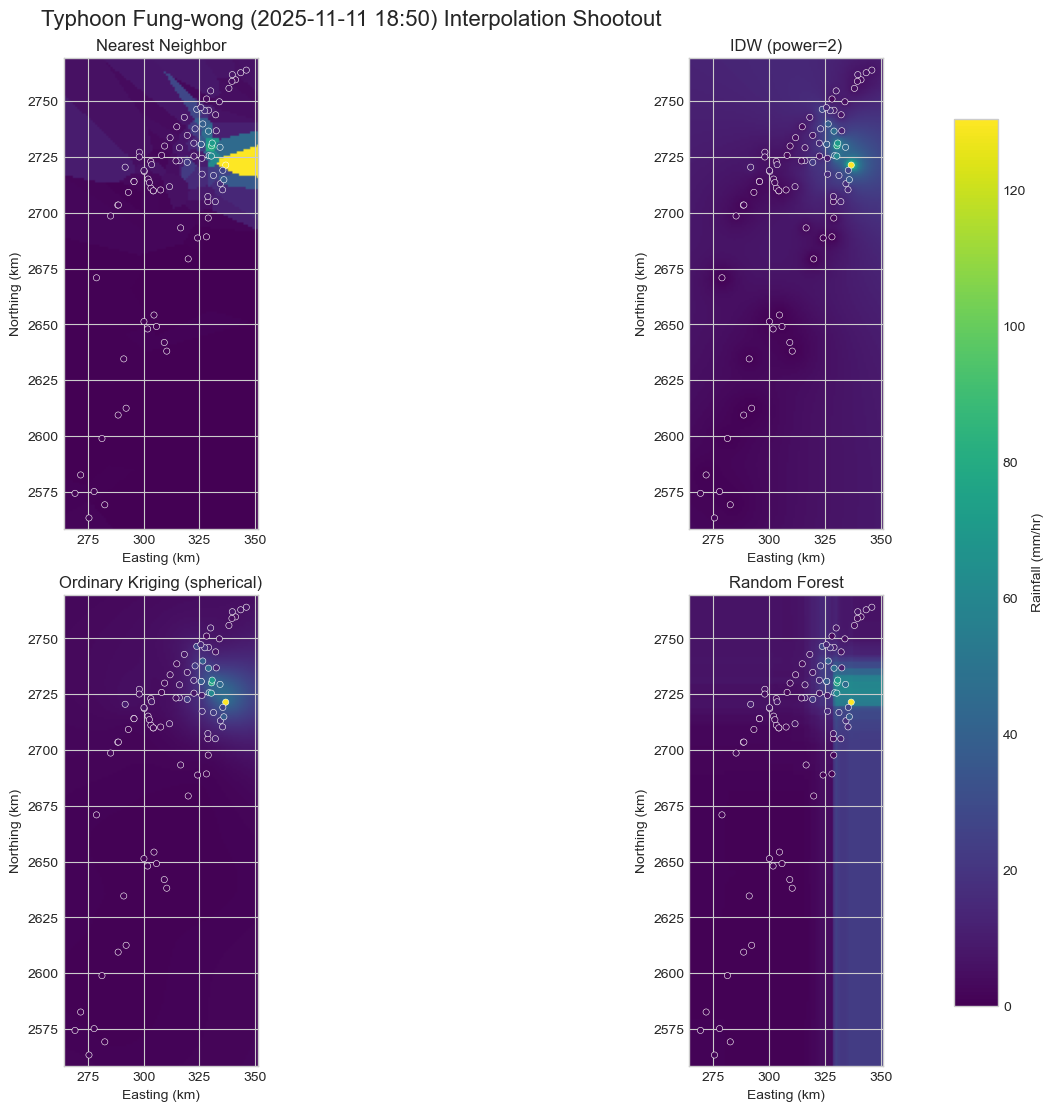

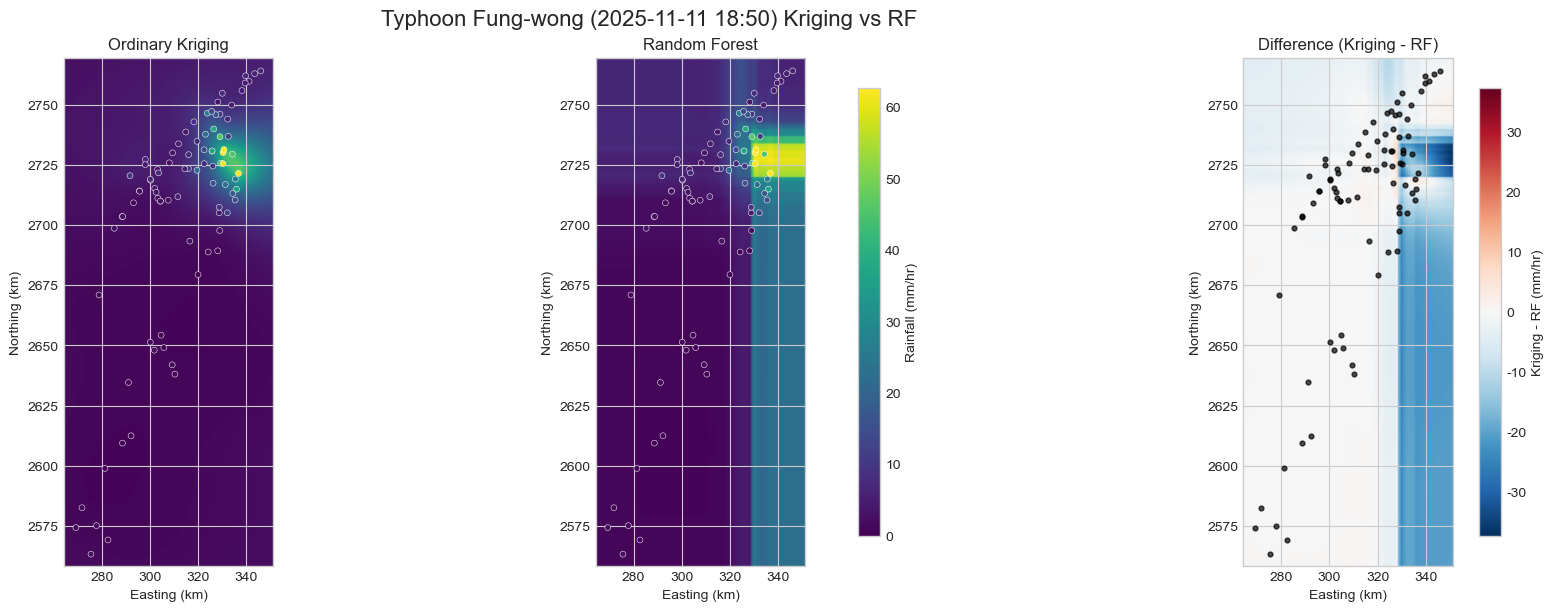

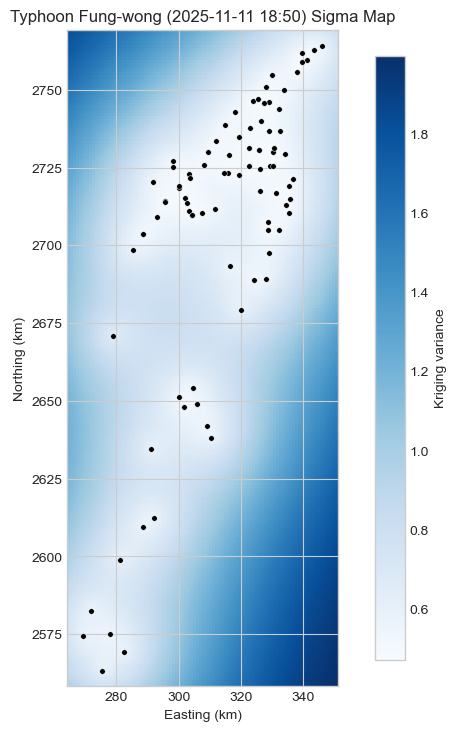

,total_stations,county_stations,positive_rain_stations,crs_after_projection,max_rain_1hr,mean_rain_1hr,grid_shape
0,1256,169,89,EPSG:3826,130.5,12.365169,"(212, 88)"


,model,sse,sill,range_m,nugget
0,spherical,0.624022,1.742654,101164.4,0.390191
1,exponential,0.698116,1.759469,98901.4,0.000000


,path,width,height,crs,dtype,transform
kriging_rainfall,D:\YongZhi\2026_RS\submission\Homework-6\krigi...,88,212,EPSG:3826,float32,"(1000.0, 0.0, 263761.4365865011, 0.0, -1000.0,..."
kriging_variance,D:\YongZhi\2026_RS\submission\Homework-6\krigi...,88,212,EPSG:3826,float32,"(1000.0, 0.0, 263761.4365865011, 0.0, -1000.0,..."
rf_rainfall,D:\YongZhi\2026_RS\submission\Homework-6\rf_ra...,88,212,EPSG:3826,float32,"(1000.0, 0.0, 263761.4365865011, 0.0, -1000.0,..."


Running event: Heavy Rain Event (2023-06-05 01:10)


## Heavy Rain Event (2023-06-05 01:10)

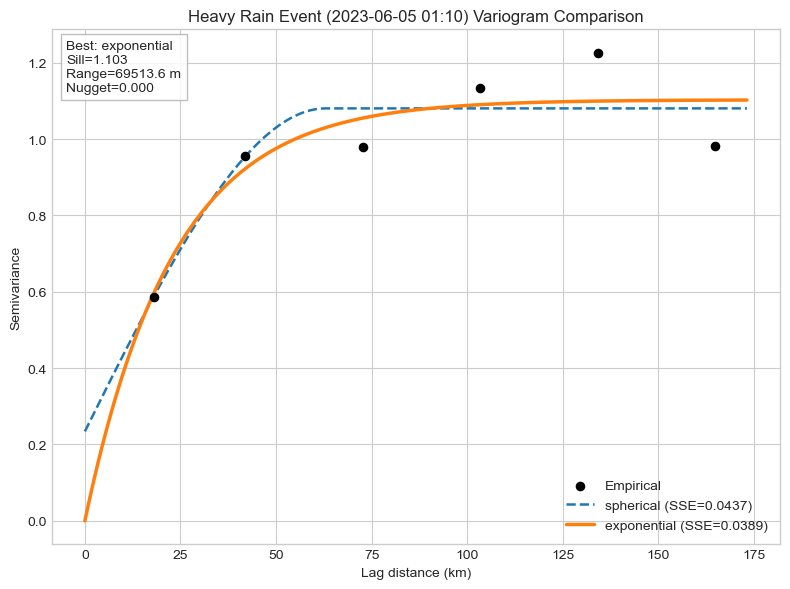

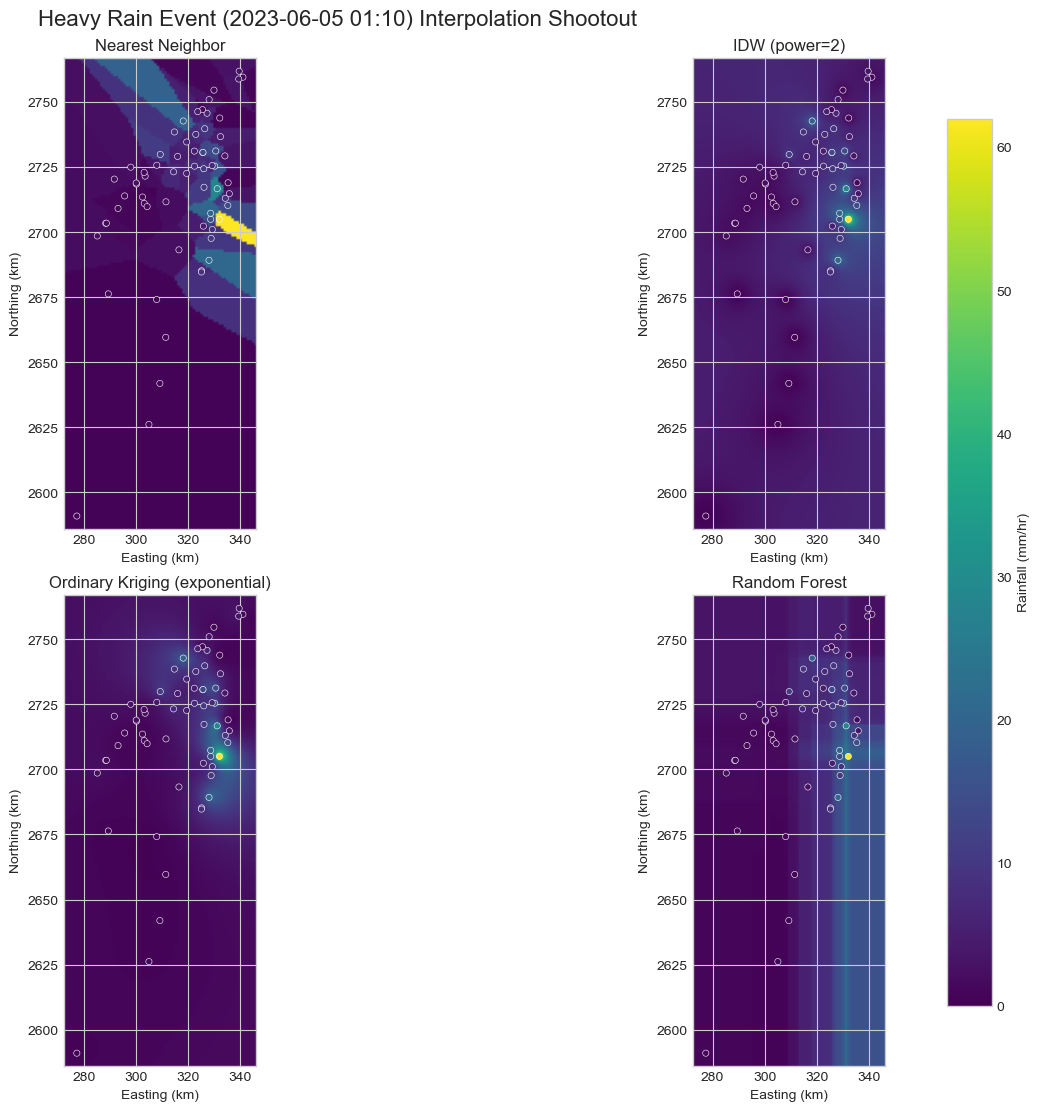

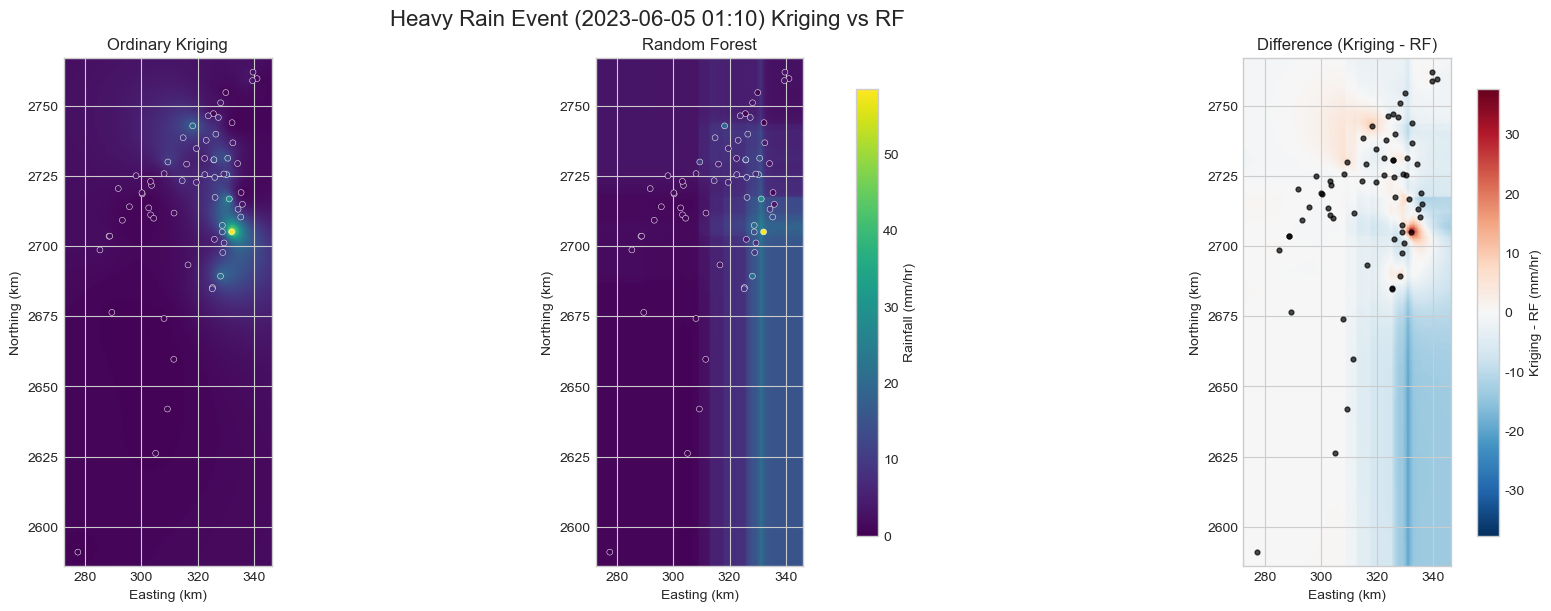

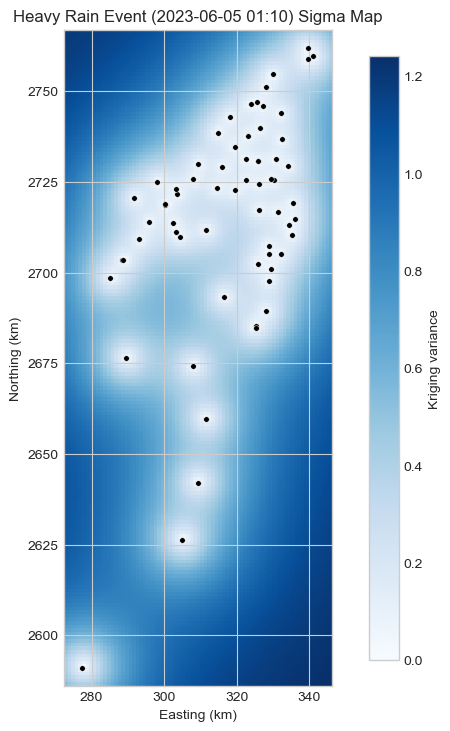

,total_stations,county_stations,positive_rain_stations,crs_after_projection,max_rain_1hr,mean_rain_1hr,grid_shape
0,142,142,66,EPSG:3826,62.0,6.840909,"(182, 75)"


,model,sse,sill,range_m,nugget
0,spherical,0.043669,1.080520,62984.9,0.234174
1,exponential,0.038883,1.103037,69513.6,0.000000


Finished all configured events.


In [30]:
results = {}

for event in EVENTS:
    print("=" * 80)
    print(f"Running event: {event['display_label']}")
    display(Markdown(f"## {event['display_label']}"))

    projected_gdf, stats = prepare_event_data(event)
    grid = build_grid(projected_gdf)
    variogram_result = fit_variogram_models(projected_gdf)
    surfaces = run_interpolations(projected_gdf, grid, variogram_result)

    figure_paths = {
        "variogram": save_variogram_figure(event, variogram_result),
        "methods_2x2": save_methods_2x2_figure(event, projected_gdf, grid, surfaces, variogram_result),
        "kriging_vs_rf_diff": save_difference_figure(event, projected_gdf, grid, surfaces),
        "sigma_map": save_sigma_figure(event, projected_gdf, grid, surfaces),
    }

    raster_checks = {}
    if event["export_geotiff"]:
        raster_paths = {
            "kriging_rainfall": save_geotiff(surfaces["z_kriging"], grid, "kriging_rainfall.tif"),
            "kriging_variance": save_geotiff(surfaces["ss_kriging"], grid, "kriging_variance.tif"),
            "rf_rainfall": save_geotiff(surfaces["z_rf"], grid, "rf_rainfall.tif"),
        }
        raster_checks = {name: validate_raster(path) for name, path in raster_paths.items()}

    results[event["event_id"]] = {
        "event": event,
        "stats": stats,
        "grid": grid,
        "variogram": variogram_result,
        "surfaces": surfaces,
        "figure_paths": figure_paths,
        "raster_checks": raster_checks,
    }

    stats_df = pd.DataFrame([stats])
    stats_df["grid_shape"] = [str(grid["shape"])]
    display(stats_df)
    variogram_df = pd.DataFrame(
        [
            {
                "model": model["model_name"],
                "sse": round(model["sse"], 6),
                "sill": round(model["sill"], 6),
                "range_m": round(model["range"], 1),
                "nugget": round(model["nugget"], 6),
            }
            for model in variogram_result["models"]
        ]
    )
    display(variogram_df)
    if raster_checks:
        display(pd.DataFrame(raster_checks).T)

print("=" * 80)
print("Finished all configured events.")


寫一段 **300 字以內的比較分析**，回答：
   - 兩個事件的 Sigma Map 有什麼差異？為什麼？
   - 哪種類型的降雨事件，Kriging 的預測信心較高？
   - 如果你是指揮官，在高 variance 區域會做什麼決策？
   - Random Forest 能提供類似的不確定性資訊嗎？為什麼？

鳳凰事件的 Sigma Map 通常會更集中在蘇澳高值核心與邊界區，表示局部極端雨量強、空間梯度陡；20230605豪雨事件的高 variance 區域較分散，反映降雨帶較廣、但部分山區仍受測站稀疏影響。Kriging 的預測信心較高等同於不確定性低，以本次分析結果，鳳凰颱風事件Sigma map藍色區域明顯較少，代表其整體不確定性較低，。若我是指揮官，對高 variance 區域不會直接把預測值當成定值，而會優先加派監測、巡查與交叉比對。Random Forest 雖可用樹間分散或 bootstrap 近似不確定性，但它沒有像 Kriging 那樣原生的空間 variance，因此意義不完全相同。

## 7. Bonus: A5 Cross-Event Comparison

把兩個事件的最佳 variogram 參數整理成加分題要求的表格格式，並補上每一列的差異原因。

In [34]:
event1 = results["fungwong"]
event2 = results["rain20230605"]
best1 = event1["variogram"]["best"]
best2 = event2["variogram"]["best"]
label1 = event1["event"]["display_label"]
label2 = event2["event"]["display_label"]

def explain_difference(v1, v2, higher_for_event1, higher_for_event2, similar_text, tolerance=0.10):
    scale = max(abs(v1), abs(v2), 1e-9)
    if abs(v1 - v2) / scale < tolerance:
        return similar_text
    return higher_for_event1 if v1 > v2 else higher_for_event2

sill_reason = explain_difference(
    best1["sill"],
    best2["sill"],
    "事件 1 較高，代表整體空間變異較強，高低雨量反差更明顯。",
    "事件 2 較高，代表整體空間變異較強，高低雨量反差更明顯。",
    "兩事件的 sill 接近，代表整體空間變異強度差異有限。",
)
range_reason = explain_difference(
    best1["range"],
    best2["range"],
    "事件 1 較大，代表空間相關延伸較遠，降雨分布較連續。",
    "事件 2 較大，代表空間相關延伸較遠，降雨分布較連續。",
    "兩事件的 range 接近，代表空間相關尺度相近。",
)
nugget_reason = explain_difference(
    best1["nugget"],
    best2["nugget"],
    "事件 1 較高，代表局部突變、微尺度變異或觀測噪音較強。",
    "事件 2 較高，代表局部突變、微尺度變異或觀測噪音較強。",
    "兩事件的 nugget 接近，代表局部擾動程度相近。",
)
best_model_reason = (
    "兩事件最佳模型相同，表示空間相關衰減型態接近。"
    if best1["model_name"] == best2["model_name"]
    else "兩事件最佳模型不同，表示空間相關衰減型態不同。"
)

display(Markdown(f"事件 1：{label1}  \事件 2：{label2}"))

comparison_df = pd.DataFrame([
    {
        "參數": "Sill",
        "事件 1": round(best1["sill"], 4),
        "事件 2": round(best2["sill"], 4),
        "差異原因": sill_reason,
    },
    {
        "參數": "Range",
        "事件 1": round(best1["range"], 1),
        "事件 2": round(best2["range"], 1),
        "差異原因": range_reason,
    },
    {
        "參數": "Nugget",
        "事件 1": round(best1["nugget"], 4),
        "事件 2": round(best2["nugget"], 4),
        "差異原因": nugget_reason,
    },
    {
        "參數": "Best Model",
        "事件 1": best1["model_name"],
        "事件 2": best2["model_name"],
        "差異原因": best_model_reason,
    },
])
comparison_df


事件 1：Typhoon Fung-wong (2025-11-11 18:50)  \事件 2：Heavy Rain Event (2023-06-05 01:10)

,參數,事件 1,事件 2,差異原因
0,Sill,1.7427,1.103,事件 1 較高，代表整體空間變異較強，高低雨量反差更明顯。
1,Range,101164.4,69513.6,事件 1 較大，代表空間相關延伸較遠，降雨分布較連續。
2,Nugget,0.3902,0.0,事件 1 較高，代表局部突變、微尺度變異或觀測噪音較強。
3,Best Model,spherical,exponential,兩事件最佳模型不同，表示空間相關衰減型態不同。


### 如果你只能用一組 Variogram 參數套用到未來所有事件，你會怎麼選？為什麼這樣做有風險？

如果只能用一組 Variogram 參數套用到未來所有事件，我會優先選擇較中庸、Range 較大且 Nugget 不過高的那組，因為它通常比較不會把局部極端尖峰直接擴散到整張圖，也比較能保留較平滑的區域結構。這樣做的風險在於，Variogram 本來就會隨降雨機制改變：集中型颱風、鋒面豪雨、午後對流雨的空間相關尺度不一樣。若硬套同一組參數，可能造成某些事件被過度平滑，另一些事件又被錯估成過度局部化，連帶讓 Kriging 預測面與 variance 判讀一起失真。